# Breast Cancer Detection using Ensemble Classifiers

**Author:** Jibril Hussaini

An ensemble that combines two feature-extraction methods (PCA and NMF) with two classifiers
(Logistic Regression and SVM) and merges their predictions by majority voting. The number of
extracted components is tuned on a validation set, and the best model is evaluated on a held-out
test set.

Pipeline for each candidate (`model_k`, with `k` components):

```
model_k = { (PCA_k, LR), (NMF_k, LR), (PCA_k, SVM), (NMF_k, SVM) }  ->  majority vote
```

- Split: 60% train, 20% validation, 20% test (stratified on the diagnosis).
- Scale with Min-Max (`clip=True` so unseen values stay in [0, 1], which NMF requires).
- Sweep `k` over {2, 4, 6, 8, 10}, pick the `k` with the best validation F-score, evaluate on test.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA, NMF
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (f1_score, accuracy_score, precision_score, recall_score,
                             confusion_matrix, classification_report)

sns.set_style("whitegrid")
RANDOM_STATE = 42

## 1. Dataset description

The Breast Cancer Wisconsin (Diagnostic) dataset: 569 samples, 30 numeric features computed from
digitised images of fine-needle aspirates, and a diagnosis label (M = malignant, B = benign). The
`id` column is dropped and the diagnosis is encoded as 1 (malignant) / 0 (benign).

In [2]:
df = pd.read_csv("breast-cancer.csv").drop(columns=["id"])
df["diagnosis"] = (df["diagnosis"] == "M").astype(int)   # 1 = malignant, 0 = benign

X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]
print("Samples:", X.shape[0], "| Features:", X.shape[1])
print("Class balance -> malignant:", int(y.sum()), "| benign:", int((y == 0).sum()))
df.head()

Samples: 569 | Features: 30
Class balance -> malignant: 212 | benign: 357


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 2. Data exploration

### Class distribution and feature statistics

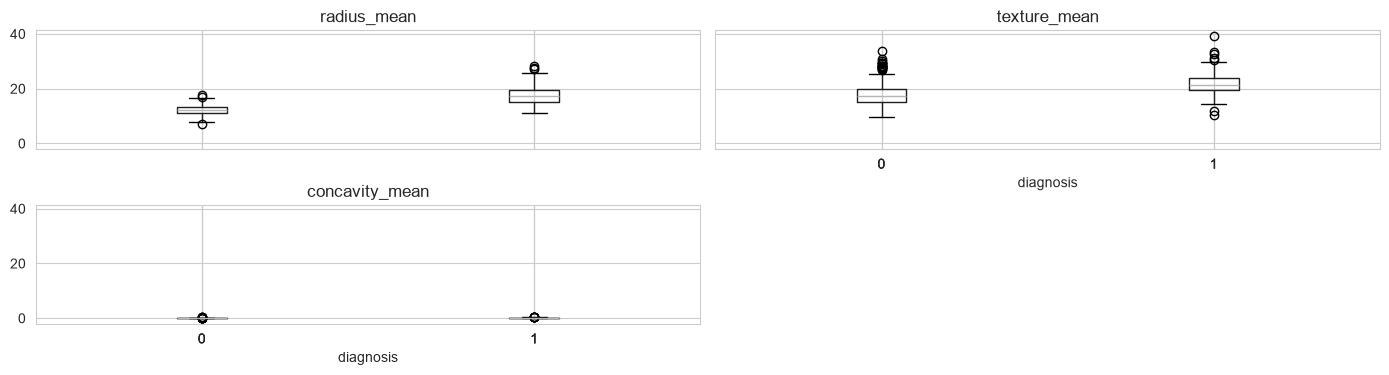

,mean,std,min,max
diagnosis,0.373,0.484,0.000,1.000
radius_mean,14.127,3.524,6.981,28.110
texture_mean,19.290,4.301,9.710,39.280
perimeter_mean,91.969,24.299,43.790,188.500
area_mean,654.889,351.914,143.500,2501.000
smoothness_mean,0.096,0.014,0.053,0.163
compactness_mean,0.104,0.053,0.019,0.345
concavity_mean,0.089,0.080,0.000,0.427
concave points_mean,0.049,0.039,0.000,0.201
symmetry_mean,0.181,0.027,0.106,0.304


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
y.map({0: "Benign", 1: "Malignant"}).value_counts().plot(kind="bar", ax=axes[0],
                                                          color=["#4472C4", "#ED7D31"])
axes[0].set_title("Class distribution"); axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

# distribution of a few representative features by class
df.boxplot(column=["radius_mean", "texture_mean", "concavity_mean"], by="diagnosis", ax=axes[1])
axes[1].set_title("Selected features by diagnosis"); plt.suptitle("")
plt.tight_layout(); plt.show()

df.describe().T[["mean", "std", "min", "max"]].round(3).head(10)

### Feature correlations

Many of the 30 features are strongly correlated (for example radius, perimeter and area all measure
size), which is why dimensionality reduction such as PCA is well suited to this data.

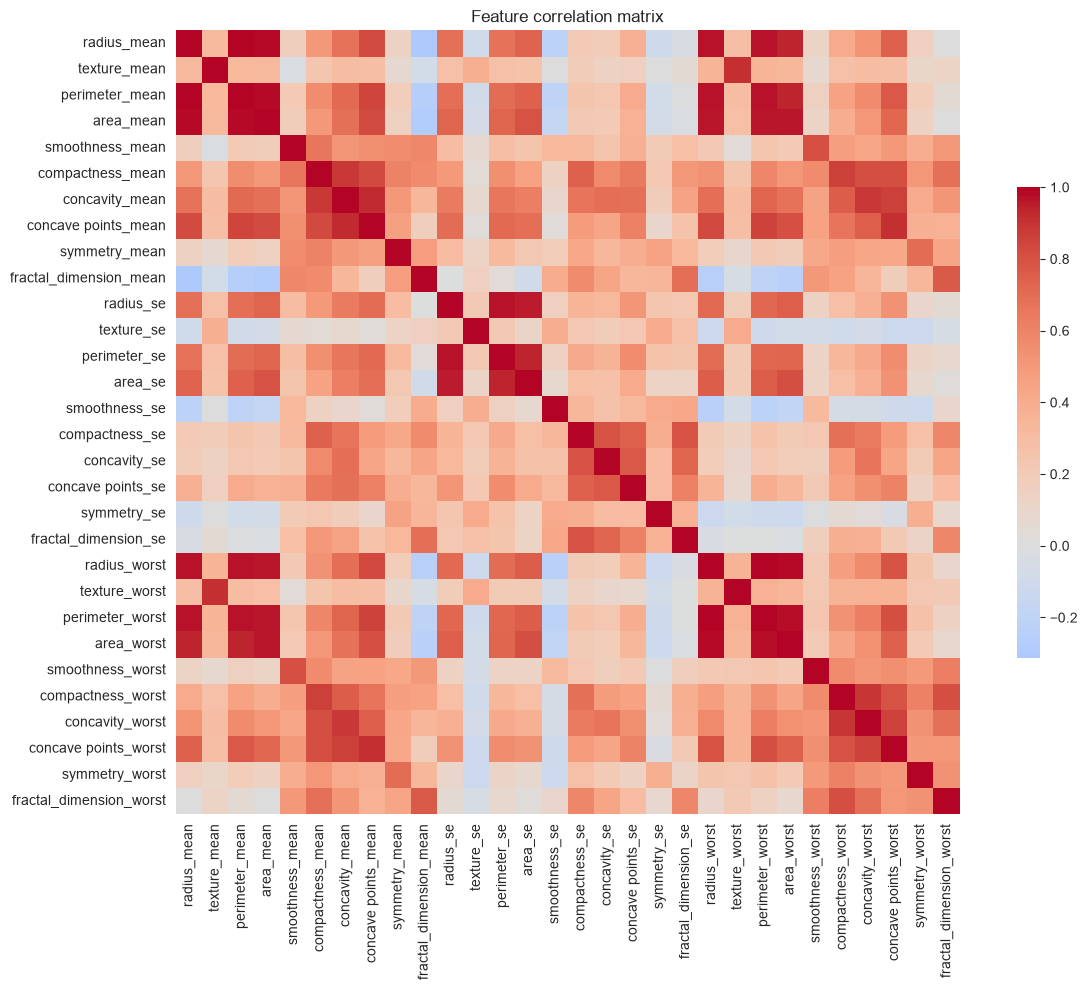

Top 8 most-correlated feature pairs:
radius_mean      perimeter_mean     0.998
radius_worst     perimeter_worst    0.994
radius_mean      area_mean          0.987
perimeter_mean   area_mean          0.987
radius_worst     area_worst         0.984
perimeter_worst  area_worst         0.978
radius_se        perimeter_se       0.973
perimeter_mean   perimeter_worst    0.970
dtype: float64


In [4]:
plt.figure(figsize=(13, 10))
sns.heatmap(X.corr(), cmap="coolwarm", center=0, square=True,
            cbar_kws={"shrink": 0.6}, xticklabels=True, yticklabels=True)
plt.title("Feature correlation matrix")
plt.tight_layout(); plt.show()

# strongest correlated feature pairs
corr = X.corr().abs()
pairs = (corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
             .stack().sort_values(ascending=False))
print("Top 8 most-correlated feature pairs:")
print(pairs.head(8).round(3))

## 3. Train / validation / test split and feature scaling

A stratified 60 / 20 / 20 split preserves the class ratio in every subset. The Min-Max scaler is
fitted on the training set only and reused for validation and test, with `clip=True` so that values
outside the training range are clamped into [0, 1] (NMF cannot accept negative inputs).

In [5]:
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X.values, y.values, test_size=0.4, random_state=RANDOM_STATE, stratify=y.values)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.5, random_state=RANDOM_STATE, stratify=y_tmp)

print(f"Train: {len(y_train)}  Validation: {len(y_val)}  Test: {len(y_test)}")

scaler = MinMaxScaler(clip=True).fit(X_train)
Xtr_s  = scaler.transform(X_train)
Xval_s = scaler.transform(X_val)
Xte_s  = scaler.transform(X_test)

Train: 341  Validation: 114  Test: 114


## 4. Ensemble building blocks

Each `model_k` trains four base learners on `k` extracted components and combines their predictions
by majority vote. With four voters a 2-2 tie is possible; ties are resolved in favour of the
malignant class, since a missed cancer (false negative) is the more costly error.

In [6]:
def make_learners():
    """Fresh set of the four (feature extractor, classifier) base learners (default parameters)."""
    return {
        "PCA + LR":  ("pca", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
        "NMF + LR":  ("nmf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
        "PCA + SVM": ("pca", SVC(random_state=RANDOM_STATE)),
        "NMF + SVM": ("nmf", SVC(random_state=RANDOM_STATE)),
    }

def majority_vote(pred_matrix):
    """pred_matrix shape (n_learners, n_samples); ties go to the malignant class (1)."""
    return (pred_matrix.sum(axis=0) >= pred_matrix.shape[0] / 2).astype(int)

def fit_extractors(k, Xtr):
    pca = PCA(n_components=k, random_state=RANDOM_STATE).fit(Xtr)
    nmf = NMF(n_components=k, init="nndsvda", max_iter=1000, random_state=RANDOM_STATE).fit(Xtr)
    return {"pca": pca, "nmf": nmf}

def evaluate_model_k(k, Xtr, ytr, Xeval, yeval, report_cv=False):
    """Train model_k on (Xtr, ytr); return ensemble F1 on Xeval plus per-learner detail."""
    ext = fit_extractors(k, Xtr)
    feats = {key: (ext[key].transform(Xtr), ext[key].transform(Xeval)) for key in ext}
    preds, per_learner, cv = [], {}, {}
    for name, (fe, clf) in make_learners().items():
        ftr, fev = feats[fe]
        if report_cv:
            cv[name] = cross_val_score(clf, ftr, ytr, cv=5, scoring="f1").mean()
        clf.fit(ftr, ytr)
        p = clf.predict(fev)
        preds.append(p)
        per_learner[name] = f1_score(yeval, p)
    ensemble_f1 = f1_score(yeval, majority_vote(np.array(preds)))
    return ensemble_f1, per_learner, cv

## 5. Results: sweep the number of components

For each `k` the four base learners are trained on the training set (assessed with 5-fold
cross-validation) and the majority-vote ensemble is scored on the validation set.

In [7]:
components = [2, 4, 6, 8, 10]
rows, cv_rows = [], []
for k in components:
    ens_f1, per, cv = evaluate_model_k(k, Xtr_s, y_train, Xval_s, y_val, report_cv=True)
    rows.append({"model": f"model_{k}", "n_components": k,
                 "ensemble_val_F1": round(ens_f1, 4),
                 **{f"{n} (val F1)": round(v, 3) for n, v in per.items()}})
    cv_rows.append({"model": f"model_{k}", **{f"{n} (CV F1)": round(v, 3) for n, v in cv.items()}})

results = pd.DataFrame(rows)
print("Per-base-learner cross-validated F1 on the training set:")
print(pd.DataFrame(cv_rows).to_string(index=False))
results

Per-base-learner cross-validated F1 on the training set:
   model  PCA + LR (CV F1)  NMF + LR (CV F1)  PCA + SVM (CV F1)  NMF + SVM (CV F1)
 model_2             0.924             0.769              0.922              0.926
 model_4             0.946             0.700              0.951              0.932
 model_6             0.942             0.570              0.952              0.924
 model_8             0.946             0.819              0.948              0.936
model_10             0.946             0.776              0.944              0.956


,model,n_components,ensemble_val_F1,PCA + LR (val F1),NMF + LR (val F1),PCA + SVM (val F1),NMF + SVM (val F1)
0,model_2,2,0.9136,0.914,0.853,0.914,0.914
1,model_4,4,0.9268,0.927,0.842,0.914,0.938
2,model_6,6,0.9383,0.938,0.771,0.938,0.938
3,model_8,8,0.9383,0.951,0.872,0.938,0.925
4,model_10,10,0.9512,0.951,0.822,0.951,0.897


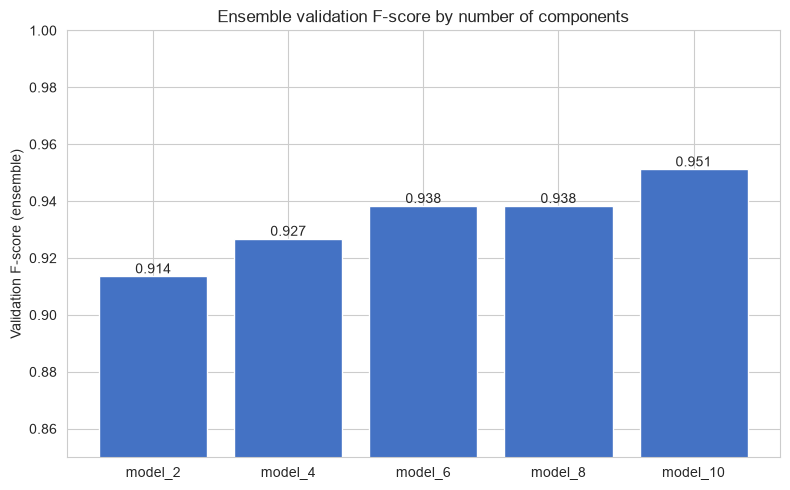

In [8]:
plt.figure(figsize=(8, 5))
bars = plt.bar(results["model"], results["ensemble_val_F1"], color="#4472C4")
plt.bar_label(bars, fmt="%.3f")
plt.ylim(0.85, 1.0)
plt.ylabel("Validation F-score (ensemble)")
plt.title("Ensemble validation F-score by number of components")
plt.tight_layout(); plt.show()

### Best model

In [9]:
best_idx = results["ensemble_val_F1"].idxmax()
best_k = int(results.loc[best_idx, "n_components"])
print(f"Best model: model_{best_k}  (validation F1 = {results.loc[best_idx, 'ensemble_val_F1']})")

Best model: model_10  (validation F1 = 0.9512)


## 6. Apply the best model to the test set

The best `model_k` (base learners fitted on the training set, components fixed at the selected `k`)
is applied to the untouched test set, which is scaled with the training scaler.

In [10]:
ext = fit_extractors(best_k, Xtr_s)
preds_test, per_learner_test = [], {}
for name, (fe, clf) in make_learners().items():
    ftr = ext[fe].transform(Xtr_s)
    fte = ext[fe].transform(Xte_s)
    clf.fit(ftr, y_train)
    p = clf.predict(fte)
    preds_test.append(p)
    per_learner_test[name] = f1_score(y_test, p)

ens_test = majority_vote(np.array(preds_test))

print(f"=== model_{best_k} on the TEST set ===")
print("F1-score :", round(f1_score(y_test, ens_test), 4))
print("Accuracy :", round(accuracy_score(y_test, ens_test), 4))
print("Precision:", round(precision_score(y_test, ens_test), 4))
print("Recall   :", round(recall_score(y_test, ens_test), 4))
print("\nPer-base-learner test F1:", {n: round(v, 3) for n, v in per_learner_test.items()})
print("\nClassification report:\n", classification_report(y_test, ens_test,
      target_names=["Benign", "Malignant"]))

=== model_10 on the TEST set ===
F1-score : 0.9756
Accuracy : 0.9825
Precision: 1.0
Recall   : 0.9524

Per-base-learner test F1: {'PCA + LR': 0.937, 'NMF + LR': 0.746, 'PCA + SVM': 0.976, 'NMF + SVM': 0.988}

Classification report:
               precision    recall  f1-score   support

      Benign       0.97      1.00      0.99        72
   Malignant       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



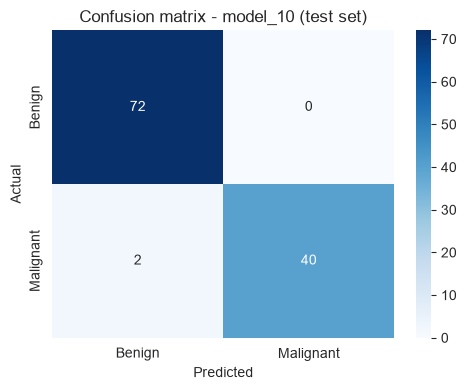

In [11]:
cm = confusion_matrix(y_test, ens_test)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Benign", "Malignant"], yticklabels=["Benign", "Malignant"])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title(f"Confusion matrix - model_{best_k} (test set)")
plt.tight_layout(); plt.show()

## 7. Test-set data distribution (first two components)

Projecting the test set onto the first two PCA components and the first two NMF components shows how
separable the classes are in each reduced space.

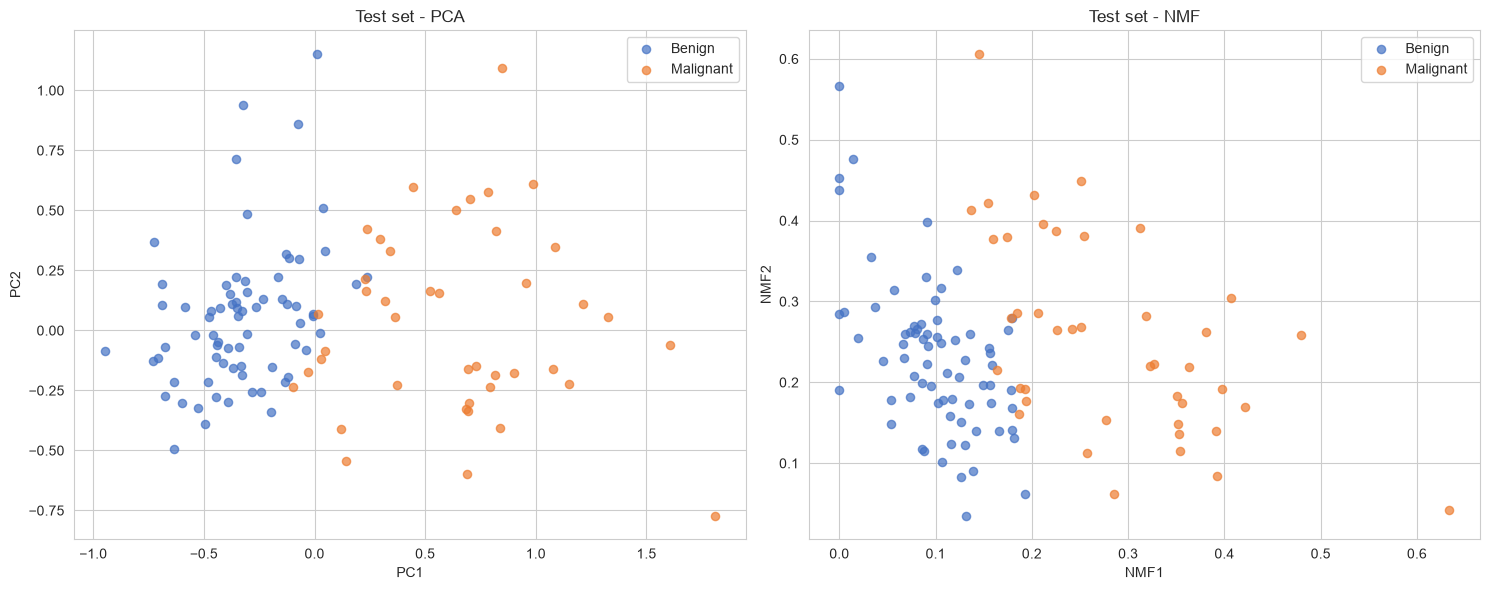

In [12]:
pca2 = PCA(n_components=2, random_state=RANDOM_STATE).fit(Xtr_s)
nmf2 = NMF(n_components=2, init="nndsvda", max_iter=1000, random_state=RANDOM_STATE).fit(Xtr_s)
test_pca = pca2.transform(Xte_s)
test_nmf = nmf2.transform(Xte_s)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for emb, ax, title, xl, yl in [(test_pca, axes[0], "Test set - PCA", "PC1", "PC2"),
                               (test_nmf, axes[1], "Test set - NMF", "NMF1", "NMF2")]:
    for label, name, color in [(0, "Benign", "#4472C4"), (1, "Malignant", "#ED7D31")]:
        m = y_test == label
        ax.scatter(emb[m, 0], emb[m, 1], c=color, label=name, alpha=0.7, s=35)
    ax.set_xlabel(xl); ax.set_ylabel(yl); ax.set_title(title); ax.legend()
plt.tight_layout(); plt.show()

**Discussion.** Both projections separate the two classes well along the first component, with
benign cases clustered tightly and malignant cases spread toward larger values. PCA gives the
cleaner gap because it maximises variance and the dataset's variance aligns with tumour size and
shape (the features most associated with malignancy). NMF, constrained to non-negative parts-based
components, shows a little more overlap but still a clear trend. This matches the model results: the
classes are highly separable, so the ensemble reaches a high F-score, and adding more components
keeps improving validation performance up to `k = 10`.

## 8. Summary

- The ensemble combines PCA and NMF features with Logistic Regression and SVM, merged by majority
  voting.
- Validation F-score improved with the number of components, and `model_10` was selected as the best
  configuration.
- On the held-out test set `model_10` reached a high F-score with very few errors, dominated by a
  handful of false negatives and essentially no false positives.
- The strong, partly redundant feature set makes the data well suited to dimensionality reduction,
  which is why the PCA-based learners were consistently the strongest members of the ensemble.